# From crop parameters to nitrogen-limited yield

WOFOST simulates crop growth. SNOMIN describes the dynamics of soil organic
matter and mineral nitrogen. Together they make yield depend on the nitrogen
the soil can supply, not only on radiation and temperature. This notebook uses
the differentiable WOFOST 8.1 SNOMIN model to recover two crop parameters from
synthetic observations of leaf area.

```
Weather
   ↓
Water balance ─────┐
                   ↓
              WOFOST 8.1
                   ↑
SNOMIN → NAVAIL ──┘
                   ↓
             Crop growth
              ↓       ↓
             LAI     TWSO
```

A potential-production run has no such soil loop. Water and nitrogen do not
limit growth, so calibrating it only exercises the crop. Here the canopy, the
soil water, and the mineral nitrogen all feed one another. `NAVAIL` is the
mineral nitrogen the crop can take up. `LAI` is the leaf area that results.
`TWSO` is the weight of the storage organs, the simulated yield.

The observations are not field measurements. They are one run of this same
model at the crop-file values of `TDWI` and `SPAN`. The search starts elsewhere,
at `TDWI` 200 kg ha$^{-1}$ and `SPAN` 25 days, and is asked to find the
crop-file values from the leaf-area series alone.

| Quantity | Used for optimization? | Shown as a model outcome? |
| --- | --- | --- |
| `LAI` | yes | yes |
| `NAVAIL` | no | yes |
| `TWSO` | no | yes |

Only `LAI` enters the loss. `NAVAIL` and `TWSO` are kept out of the optimizer
so that, afterwards, they show how a change in the crop parameters travels
through the coupled crop–soil system.

The notebook does not use a repository checkout. The next cells install
`diffwofost` from this branch, because WOFOST 8.1 is not in the released
package yet, and they download the weather and crop files. One season takes a
few seconds on CPU. A hundred optimization steps takes about fifteen minutes.
After the install, restart the kernel if the import cell still cannot see
`pcse`.


## 1. Setup

Install this branch into the kernel that is running the notebook. That install
brings in PCSE as well.


In [ ]:
%pip install --quiet "diffwofost @ git+https://github.com/WUR-AI/diffWOFOST.git@wofost81-snomin" matplotlib


In [ ]:
import urllib.request
from pathlib import Path

DATA = Path("snomin_calibration_data")
CROP_DIR = DATA / "crop"
CROP_DIR.mkdir(parents=True, exist_ok=True)
WEATHER = DATA / "weather_wageningen.xlsx"

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/ajwdewit/pcse_notebooks/master/data/meteo/weather_wageningen.xlsx",
    WEATHER,
)
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/WUR-AI/NUE_PCSE-Gym/main/pcse_gym/envs/configs/crop/winterwheat.yaml",
    CROP_DIR / "winterwheat.yaml",
)
(CROP_DIR / "crops.yaml").write_text("available_crops:\n- winterwheat\n")
print(f"Weather: {WEATHER.resolve()}")
print(f"Crop file: {(CROP_DIR / 'winterwheat.yaml').resolve()}")


In [ ]:
import datetime as dt
import inspect
import tempfile
import textwrap
from pathlib import Path

import torch
import yaml
from pcse.input import ExcelWeatherDataProvider
from pcse.input import WOFOST81SiteDataProvider_SNOMIN
from pcse.input import YAMLAgroManagementReader
from pcse.input import YAMLCropDataProvider
from pcse.models import Wofost81_NWLP_MLWB_SNOMIN
from pcse.soil.soil_profile import SoilProfile

from diffwofost.physical_models.config import ComputeConfig
from diffwofost.physical_models.config import Configuration
from diffwofost.physical_models.crop.wofost81 import Wofost81
from diffwofost.physical_models.engine import Engine
from diffwofost.physical_models.parameter_providers import ParameterProvider
from diffwofost.physical_models.soil.soil_wrappers import SoilModuleWrapper_NWLP_MLWB_SNOMIN

ComputeConfig.set_dtype(torch.float64)
ComputeConfig.set_device("cpu")

SOWING = dt.date(2013, 10, 23)
SEASON_END = dt.date(2014, 7, 31)
CROP_NAME = "winterwheat"
VARIETY_NAME = "Arminda"
FERTILIZER_DATES = (SOWING, dt.date(2014, 3, 26), dt.date(2014, 4, 29))


## 2. The model and the experiment

The crop is winter wheat variety `Arminda`, from the crop file used by the NUE
PCSE-Gym winter-wheat environment. In that file the total dry weight at
emergence, `TDWI`, is 593 kg ha$^{-1}$, and the leaf lifespan `SPAN` is 35
days. `TDWI` sets how large the canopy is at the start. `SPAN` is the lifespan,
in days, of leaves that grew at 35 °C, so it controls how soon the canopy
senesces. An earlier trial with `Winter_wheat_101` started from only
50 kg ha$^{-1}$ and never grew a leaf-area index above about 1.6, even with a
large nitrogen supply. `Arminda` reaches a peak near 5, which is a plausible
winter-wheat canopy.

The soil profile is the worked example in the PCSE `SoilProfile` docstring.
Site parameters use the defaults of `WOFOST81SiteDataProvider_SNOMIN`, plus the
four values that provider requires: initial available water `WAV`, atmospheric
`CO2`, and the initial ammonium and nitrate in each soil layer.

Weather is the Wageningen record shipped with the PCSE notebook that runs
WOFOST 8.1 and SNOMIN on SoilGrids. Sowing is 23 October 2013, and the
simulation stops at harvest on 31 July 2014. That window includes winter, the
spring sidedressings, and the summer in which the leaves senesce. The file
stores minimum and maximum temperature. Daily mean temperature is their
average, and daytime temperature `DTEMP` is the average of that mean and the
maximum, as in the WOFOST 8.1 tests.

Nitrogen is applied as three synthetic dressings, 180 kg N ha$^{-1}$ in total.
Each dressing is 60 kg N ha$^{-1}$, half ammonium and half nitrate, worked into
the top 10 cm, with no organic matter. The first goes on at sowing. The other
two are sidedressings on 26 March and 29 April 2014, during stem elongation.


In [5]:
def example_soil():
    lines = inspect.getdoc(SoilProfile).splitlines()
    start = next(i for i, line in enumerate(lines) if line.strip() == "SoilLayerTypes:")
    end = next(i for i, line in enumerate(lines) if line.strip().startswith("GroundWater:"))
    parsed = yaml.safe_load(textwrap.dedent("\n".join(lines[start : end + 1])))
    profile = parsed["SoilProfileDescription"]
    if "FSOMI" not in profile["SubSoilType"]:
        profile["SubSoilType"]["FSOMI"] = 0.0
    rootable = sum(layer["Thickness"] for layer in profile["SoilLayers"])
    return {"RDMSOL": float(rootable), "SoilProfileDescription": profile}


def weather_rows(start, end):
    provider = ExcelWeatherDataProvider(WEATHER)
    names = (
        "DAY", "LAT", "LON", "ELEV", "IRRAD", "TMIN", "TMAX",
        "VAP", "WIND", "RAIN", "E0", "ES0", "ET0",
    )
    rows = []
    day = start
    while day <= end:
        container = provider(day)
        item = {name: getattr(container, name) for name in names}
        item["TEMP"] = 0.5 * (item["TMIN"] + item["TMAX"])
        item["DTEMP"] = 0.5 * (item["TEMP"] + item["TMAX"])
        rows.append(item)
        day += dt.timedelta(days=1)
    return rows


def agro(start):
    harvest = start + dt.timedelta(days=300)
    dressings = tuple(zip(FERTILIZER_DATES, (60, 60, 60), strict=True))
    events = "\n".join(
        f"""        - {day.isoformat()}:
            amount: {amount}
            application_depth: 10
            cnratio: 0
            initial_age: 0
            f_NH4N: 0.5
            f_NO3N: 0.5
            f_orgmat: 0"""
        for day, amount in dressings
    )
    with tempfile.NamedTemporaryFile("w", suffix=".yaml", delete=False) as handle:
        path = Path(handle.name)
        handle.write(
            f"""
AgroManagement:
- {start.isoformat()}:
    CropCalendar:
        crop_name: {CROP_NAME}
        variety_name: {VARIETY_NAME}
        crop_start_date: {start.isoformat()}
        crop_start_type: sowing
        crop_end_date: {harvest.isoformat()}
        crop_end_type: harvest
        max_duration: 300
    TimedEvents:
      - event_signal: apply_n_snomin
        name: Synthetic nitrogen
        comment: amount is kg N/ha because the amendment is entirely mineral
        events_table:
{events}
    StateEvents: null
"""
        )
    try:
        return YAMLAgroManagementReader(str(path))
    finally:
        path.unlink(missing_ok=True)


rows = weather_rows(SOWING, SEASON_END)
crop = YAMLCropDataProvider(Wofost81_NWLP_MLWB_SNOMIN, fpath=CROP_DIR, force_reload=True)
soil = example_soil()
n_layers = len(soil["SoilProfileDescription"]["SoilLayers"])
site = WOFOST81SiteDataProvider_SNOMIN(
    WAV=20.0, CO2=360.0, NH4I=[10.0] * n_layers, NO3I=[1.0] * n_layers
)
campaign = agro(rows[0]["DAY"])
params = ParameterProvider(cropdata=crop, soildata=soil, sitedata=site)
params.set_active_crop(CROP_NAME, VARIETY_NAME, "sowing", "harvest")
true_span = float(params["SPAN"])
true_tdwi = float(params["TDWI"])
print(
    f"Crop-file SPAN = {true_span:.2f} days, TDWI = {true_tdwi:.1f} kg/ha. "
    f"Simulation = {rows[0]['DAY']} to {rows[-1]['DAY']}."
)


Crop-file SPAN = 35.00 days, TDWI = 593.0 kg/ha. Simulation = 2013-10-23 to 2014-07-31.


## 3. A first simulation

`NAVAIL` is the mineral nitrogen available to the crop, in kg N ha$^{-1}$. In
the SNOMIN configuration it changes every day. Mineralisation and fertilizer
add to it. Nitrification moves ammonium to nitrate. Immobilisation, crop
uptake, leaching and denitrification remove it, and the water content of the
soil changes how fast those processes run. The vertical lines on the middle
panel are the three dressings, 60 kg N ha$^{-1}$ each.

`TWSO` is the weight of the storage organs, in kg ha$^{-1}$ of dry matter. At
harvest it is the simulated grain yield. It is not used to fit the parameters.
It is here so the season has an agronomic endpoint, not only a leaf-area curve.

The figure below is the reference season: the crop-file values of `TDWI` and
`SPAN`, which are also the synthetic observations.


Reference peak LAI = 4.87. Harvest TWSO = 8832 kg/ha.


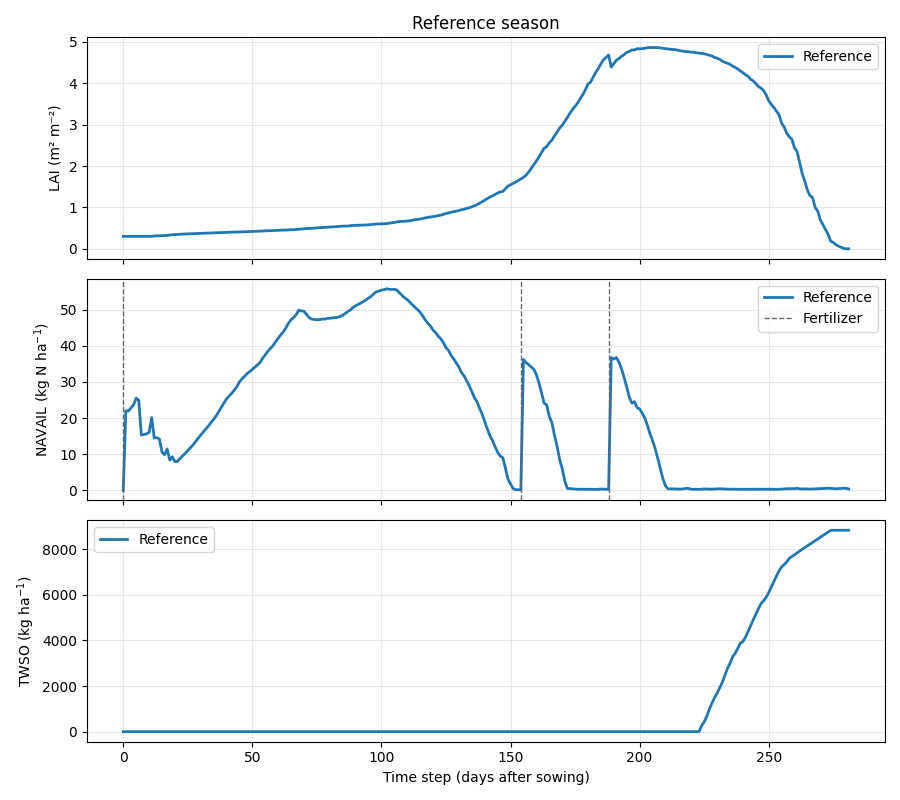

In [6]:
config = Configuration(
    CROP=Wofost81,
    SOIL=SoilModuleWrapper_NWLP_MLWB_SNOMIN,
    OUTPUT_VARS=["LAI", "NAVAIL", "TWSO"],
)


def run(span, tdwi):
    """One SNOMIN season. Either argument may be a tensor that requires a gradient."""
    params.set_override("SPAN", span, check=False)
    params.set_override("TDWI", tdwi, check=False)
    model = Engine(config)
    model.setup(params, iter(rows), campaign)
    model.run_till(rows[-1]["DAY"])
    output = model.get_output()
    return {
        name: torch.stack([day[name].reshape(()) for day in output])
        for name in ("LAI", "NAVAIL", "TWSO")
    }


def season_figure(series, title):
    """LAI, NAVAIL and TWSO. `series` maps a legend label to a `run()` result."""
    import matplotlib.pyplot as plt

    days = range(len(next(iter(series.values()))["LAI"]))
    fertilizer_days = [(day - SOWING).days for day in FERTILIZER_DATES]
    fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
    panels = (
        ("LAI", "LAI (m² m⁻²)"),
        ("NAVAIL", "NAVAIL (kg N ha$^{-1}$)"),
        ("TWSO", "TWSO (kg ha$^{-1}$)"),
    )
    styles = (("-", 2), (":", 2), ("--", 2))
    for ax, (key, ylabel) in zip(axes, panels, strict=True):
        for (label, trajectory), (linestyle, width) in zip(series.items(), styles):
            values = trajectory[key]
            values = values.detach().numpy() if torch.is_tensor(values) else values
            ax.plot(days, values, label=label, linewidth=width, linestyle=linestyle)
        if key == "NAVAIL":
            for index, day in enumerate(fertilizer_days):
                ax.axvline(
                    day,
                    color="0.4",
                    linestyle="--",
                    linewidth=1,
                    label="Fertilizer" if index == 0 else None,
                )
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
        ax.legend()
    axes[0].set_title(title)
    axes[-1].set_xlabel("Time step (days after sowing)")
    fig.tight_layout()
    return fig


with torch.no_grad():
    observed = run(
        torch.tensor(true_span, dtype=torch.float64),
        torch.tensor(true_tdwi, dtype=torch.float64),
    )
print(
    f"Reference peak LAI = {observed['LAI'].max().item():.2f}. "
    f"Harvest TWSO = {observed['TWSO'][-1].item():.0f} kg/ha."
)
season_figure({"Reference": observed}, "Reference season")


## 4. What is differentiable?

Calibration here is ordinary gradient descent on a PyTorch graph.

1. Treat `TDWI` and `SPAN` as tensors.
2. Run WOFOST 8.1 with SNOMIN for the whole season.
3. Compute a loss from the simulated leaf area and the reference leaf area.
4. Call `loss.backward()`. PyTorch walks the season in reverse and fills
   `.grad` on each parameter.
5. Read those gradients and update the parameters.
6. Repeat.

Most WOFOST equations are smooth arithmetic, so PyTorch can differentiate them
directly. A few processes are thresholds. Leaf cohorts die on a hard comparison
with `SPAN`: once the age of a cohort passes the lifespan, the forward pass
removes it exactly as WOFOST does. A straight-through estimator is used only
while `SPAN` itself requires a gradient. In the forward pass the hard threshold
is kept. In the backward pass a smooth step stands in for it, so the optimizer
receives a usable derivative instead of a zero from the dead branch of the
comparison.

The cell below takes one step of that procedure from the starting values,
`SPAN` 25 days and `TDWI` 200 kg ha$^{-1}$, and prints the two gradients. The
search itself is the longer loop in the next section. Logging a tensor with
`.detach().item()` reads out a number without cutting the graph that
`backward` still needs.


In [7]:
probe_span = torch.tensor(25.0, dtype=torch.float64, requires_grad=True)
probe_tdwi = torch.tensor(200.0, dtype=torch.float64, requires_grad=True)
probe = run(probe_span, probe_tdwi)
probe_loss = torch.mean(torch.abs(probe["LAI"] - observed["LAI"]))
probe_loss.backward()
print(
    f"Loss {probe_loss.detach().item():.4f}, "
    f"d(loss)/d(SPAN) {probe_span.grad.item():.4e}, "
    f"d(loss)/d(TDWI) {probe_tdwi.grad.item():.4e}"
)


Loss 1.0143, d(loss)/d(SPAN) -6.4281e-03, d(loss)/d(TDWI) -2.2029e-03


## 5. Gradient-based calibration

`LAI` is the calibration target because it is a time series. It records when
the canopy appears, how large it becomes, and when it senesces. The aim is not
to fit yield directly. It is to see whether the differentiable model can
recover the crop parameters that produced that growth.

Each parameter is kept inside a fixed range by storing it as a logit and
mapping that logit through a sigmoid. `SPAN` is limited to 10–60 days and
starts at 25. `TDWI` is limited to 50–1200 kg ha$^{-1}$ and starts at 200. The
loss is the mean absolute error of daily `LAI`.

The two parameters can stand in for each other. A longer leaf life raises late
leaf area in much the same way as a larger biomass at emergence raises early
leaf area, and both change the growth that follows. Early in the search,
`SPAN` can therefore walk past 35 while `TDWI` is still well below 593. The
printed gradient is the derivative of the loss with respect to the unbounded
logit, not with respect to the parameter in days or kg ha$^{-1}$.


In [7]:
class BoundedParameter(torch.nn.Module):
    def __init__(self, low, high, init_value):
        super().__init__()
        self.low = low
        self.high = high
        init_norm = (init_value - low) / (high - low)
        self.raw = torch.nn.Parameter(
            torch.logit(torch.tensor(init_norm, dtype=torch.float64), eps=1e-6)
        )

    def forward(self):
        return self.low + (self.high - self.low) * torch.sigmoid(self.raw)


SPAN_MIN, SPAN_MAX, SPAN_INIT = 10.0, 60.0, 25.0
TDWI_MIN, TDWI_MAX, TDWI_INIT = 50.0, 1200.0, 200.0
span = BoundedParameter(SPAN_MIN, SPAN_MAX, SPAN_INIT)
tdwi = BoundedParameter(TDWI_MIN, TDWI_MAX, TDWI_INIT)
optimizer = torch.optim.Adam(list(span.parameters()) + list(tdwi.parameters()), lr=0.05)

loss_history = []
span_history = []
tdwi_history = []

for step in range(100):
    optimizer.zero_grad()
    simulated = run(span(), tdwi())
    loss = torch.mean(torch.abs(simulated["LAI"] - observed["LAI"]))
    loss.backward()
    span_gradient = span.raw.grad
    tdwi_gradient = tdwi.raw.grad
    optimizer.step()
    loss_history.append(loss.detach().item())
    span_history.append(span().detach().item())
    tdwi_history.append(tdwi().detach().item())
    print(
        f"Step {step}, loss {loss_history[-1]:.4f}, "
        f"SPAN {span_history[-1]:.2f}, TDWI {tdwi_history[-1]:.1f}, "
        f"grads {span_gradient.item():.4e} {tdwi_gradient.item():.4e}"
    )

print(
    f"Crop-file SPAN {true_span:.2f}, TDWI {true_tdwi:.1f}. "
    f"Calibrated SPAN {span().detach().item():.2f}, TDWI {tdwi().detach().item():.1f}."
)


Step 0, loss 1.0143, SPAN 25.53, TDWI 206.6, grads -6.7495e-02 -2.8733e-01
Step 1, loss 0.9808, SPAN 26.07, TDWI 213.5, grads -7.0184e-02 -2.9594e-01
Step 2, loss 0.9437, SPAN 26.62, TDWI 220.7, grads -7.9048e-02 -3.0484e-01
Step 3, loss 0.9095, SPAN 27.19, TDWI 228.1, grads -8.0063e-02 -3.1308e-01
Step 4, loss 0.8725, SPAN 27.76, TDWI 235.8, grads -8.1407e-02 -3.2127e-01
Step 5, loss 0.8331, SPAN 28.34, TDWI 243.8, grads -8.4493e-02 -3.2984e-01
Step 6, loss 0.7980, SPAN 28.93, TDWI 252.1, grads -9.1072e-02 -3.3723e-01
Step 7, loss 0.7584, SPAN 29.54, TDWI 260.6, grads -9.8199e-02 -3.4556e-01
Step 8, loss 0.7188, SPAN 30.15, TDWI 269.5, grads -1.0173e-01 -3.5340e-01
Step 9, loss 0.6791, SPAN 30.77, TDWI 278.7, grads -9.9835e-02 -3.6088e-01
Step 10, loss 0.6373, SPAN 31.40, TDWI 288.2, grads -1.1337e-01 -3.6923e-01
Step 11, loss 0.5945, SPAN 32.05, TDWI 298.0, grads -1.1986e-01 -3.7667e-01
Step 12, loss 0.5529, SPAN 32.70, TDWI 308.2, grads -1.2420e-01 -3.8368e-01
Step 13, loss 0.5124, 

## 6. Optimization results

The upper panel is the leaf-area error at each Adam step. The lower panel
shows the two parameters, with dotted lines at the crop-file values. Because
the parameters trade off, the error can rise again for a while after `SPAN`
has already passed 35, and then fall once `TDWI` catches up. With about a
hundred steps both parameters arrive close to the crop file.


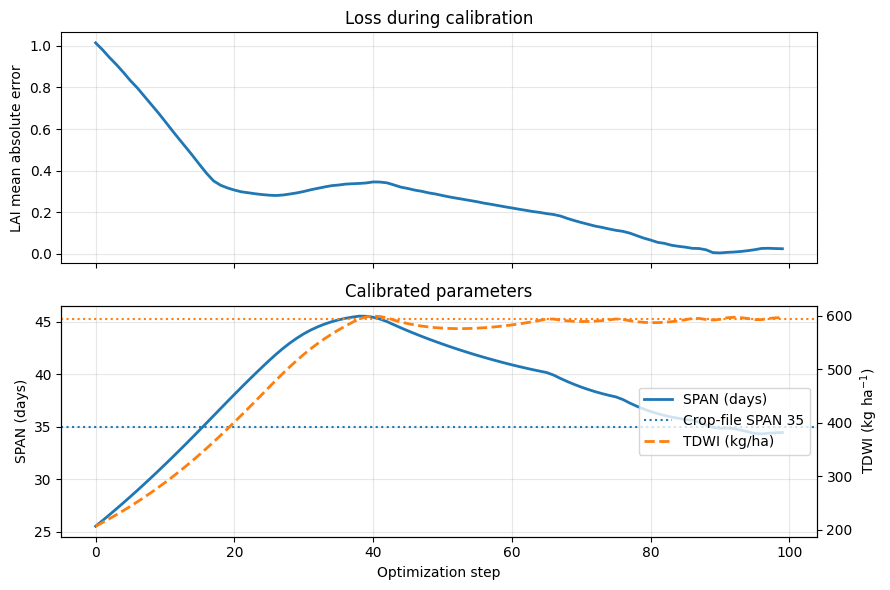

Calibrated: SPAN = 34.45, TDWI = 596.3
Crop file:  SPAN = 35.00, TDWI = 593.0


In [8]:
import matplotlib.pyplot as plt

steps = range(len(loss_history))
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].plot(steps, loss_history, linewidth=2)
axes[0].set_ylabel("LAI mean absolute error")
axes[0].set_title("Loss during calibration")
axes[0].grid(True, alpha=0.3)

axes[1].plot(steps, span_history, label="SPAN (days)", linewidth=2)
axes[1].axhline(true_span, color="C0", linestyle=":", label=f"Crop-file SPAN {true_span:.0f}")
tdwi_axis = axes[1].twinx()
tdwi_axis.plot(steps, tdwi_history, color="C1", linestyle="--", label="TDWI (kg/ha)", linewidth=2)
tdwi_axis.axhline(true_tdwi, color="C1", linestyle=":")
axes[1].set_xlabel("Optimization step")
axes[1].set_ylabel("SPAN (days)")
tdwi_axis.set_ylabel("TDWI (kg ha$^{-1}$)")
axes[1].set_title("Calibrated parameters")
handles, labels = axes[1].get_legend_handles_labels()
tdwi_handles, tdwi_labels = tdwi_axis.get_legend_handles_labels()
axes[1].legend(handles + tdwi_handles, labels + tdwi_labels, loc="center right")
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Calibrated: SPAN = {span().detach().item():.2f}, TDWI = {tdwi().detach().item():.1f}")
print(f"Crop file:  SPAN = {true_span:.2f}, TDWI = {true_tdwi:.1f}")


## 7. What happened to the model?

Although only `LAI` is used in the optimization, the calibrated parameters
affect the whole simulation, including the nitrogen the crop leaves in the soil
and the storage-organ weight at harvest. The figure compares three runs. The
reference is the crop file. The initial run is the starting guess, `SPAN` 25
days and `TDWI` 200 kg ha$^{-1}$. The optimized run is the end of the search.

The leaf-area panel is the quantity the loss saw. The nitrogen and yield
panels were not in the loss. If the search has recovered the crop file, the
optimized curves lie on the reference there as well.


Harvest TWSO: reference 8832, initial 5802, optimized 8746 kg/ha.


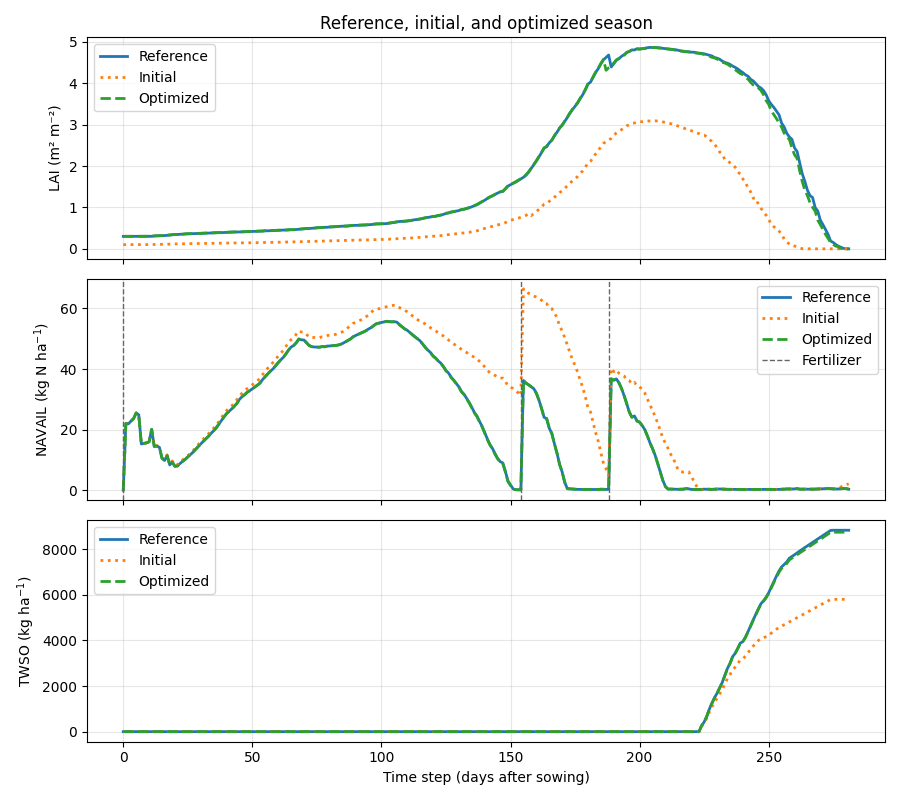

In [9]:
with torch.no_grad():
    initial = run(
        torch.tensor(SPAN_INIT, dtype=torch.float64),
        torch.tensor(TDWI_INIT, dtype=torch.float64),
    )
    optimized = run(span().detach(), tdwi().detach())

print(
    f"Harvest TWSO: reference {observed['TWSO'][-1].item():.0f}, "
    f"initial {initial['TWSO'][-1].item():.0f}, "
    f"optimized {optimized['TWSO'][-1].item():.0f} kg/ha."
)
season_figure(
    {"Reference": observed, "Initial": initial, "Optimized": optimized},
    "Reference, initial, and optimized season",
)


## 8. Interpretation

The search recovers both parameters, but not along a straight path. `SPAN` and
`TDWI` are only weakly separate in a leaf-area series: a longer leaf life can
imitate a larger biomass at emergence for part of the season. That is why
`SPAN` overshoots 35 while `TDWI` is still climbing, and why the loss is not
monotone. A hundred steps is enough for both to settle next to the crop-file
values, 35 days and 593 kg ha$^{-1}$.

`NAVAIL` shows that the soil nitrogen model is actually in the loop. It jumps
at the three dressings and then declines as the crop takes nitrogen up. `TWSO`
shows that the same parameters change the yield, even though yield was never
shown to the optimizer. Fitting the canopy was enough to restore the
storage-organ weight as well.
